In [1]:
# Or use the pip magic command
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ========================
# CIFAR-10 CNN with Optimized Training
# ========================
# Key improvements:
# - Lower, more stable learning rates (0.0001-0.0005)
# - Simplified architectures for better convergence
# - Learning rate warmup for first 5 epochs
# - Improved batch normalization (before activation)
# - Enhanced dropout strategy with SpatialDropout2D and progressive rates
# - Multiple normalization options ([0,1], [-1,1], Z-score)
# - Comprehensive data validation and statistics
# - Gentler data augmentation for stability
# ========================
# Import Libraries
# ========================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import random
import tensorflow.keras as keras
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import pandas as pd
import json

# Additional imports for enhanced evaluation
try:
    from statsmodels.stats.contingency_tables import mcnemar
    STATSMODELS_AVAILABLE = True
except ImportError:
    STATSMODELS_AVAILABLE = False
    print("ℹ️  statsmodels not available - McNemar's test will be skipped")
    print("   Install with: pip install statsmodels")


# ========================
# Reproducibility Setup
# ========================
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

Loading and preprocessing CIFAR-10 data...
Applying data normalization...
Applied [-1,1] normalization
  x_train range: [-1.000, 1.000]
  x_test range: [-1.000, 1.000]
  Per-channel means: [-0.01720063 -0.03568322 -0.10693764]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


  Per-channel stds: [0.49406543 0.48696858 0.52317506]

Data validation:
  Any NaN values: False
  Any infinite values: False
  Data type: float32
  Memory usage: 585.9 MB


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9607843..0.99215686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.84313726..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.96862745..0.8352941].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.99215686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9764706].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.94509804..0.9529412].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.92941177..0.9450980

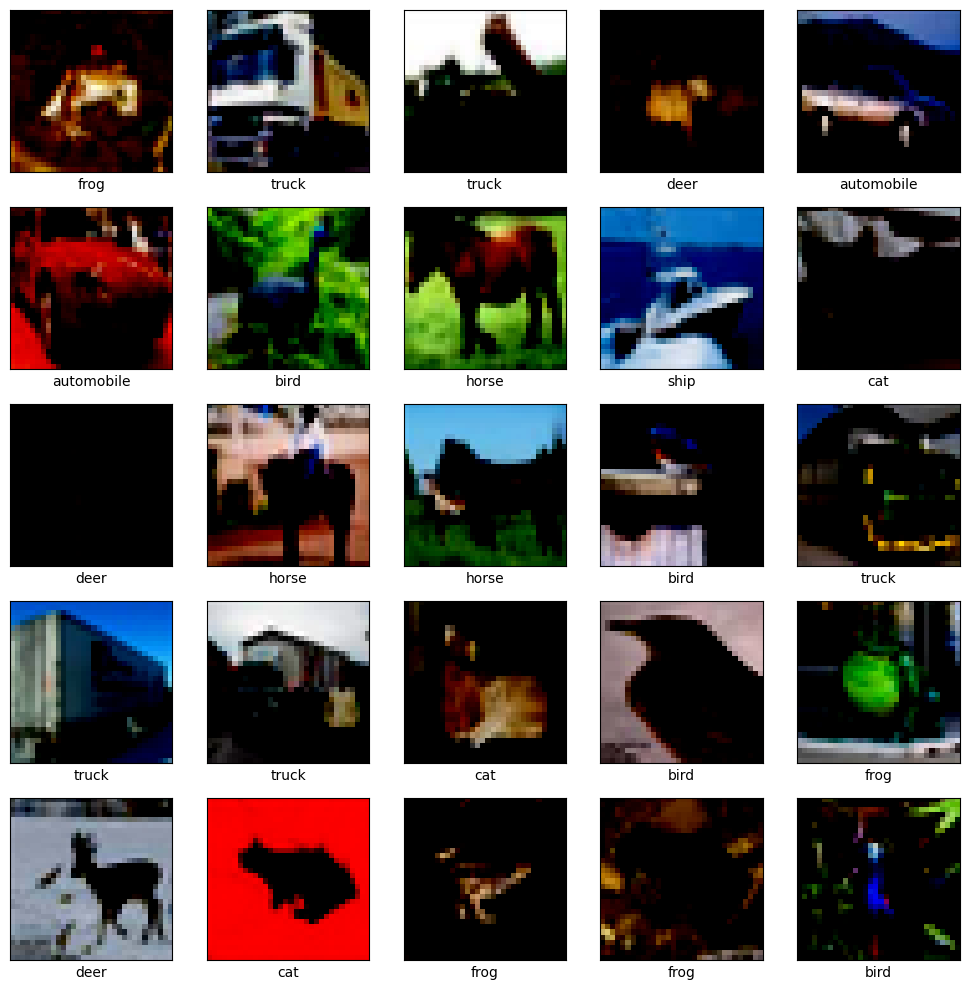

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


Training samples: 50000, Test samples: 10000
Image shape: (32, 32, 3), Number of classes: 10

Class distribution in training set:
  airplane: 5000 images
  automobile: 5000 images
  bird: 5000 images
  cat: 5000 images
  deer: 5000 images
  dog: 5000 images
  frog: 5000 images
  horse: 5000 images
  ship: 5000 images
  truck: 5000 images

Data types and ranges:
  x_train dtype: float32, range: [-1.000, 1.000]
  x_test dtype: float32, range: [-1.000, 1.000]
  y_train dtype: uint8, unique values: [0 1 2 3 4 5 6 7 8 9]
  y_test dtype: uint8, unique values: [0 1 2 3 4 5 6 7 8 9]

One-hot encoding verification:
  y_train_cat shape: (50000, 10)
  y_test_cat shape: (10000, 10)
  Sample one-hot vector: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
  Corresponding label: 6 -> frog


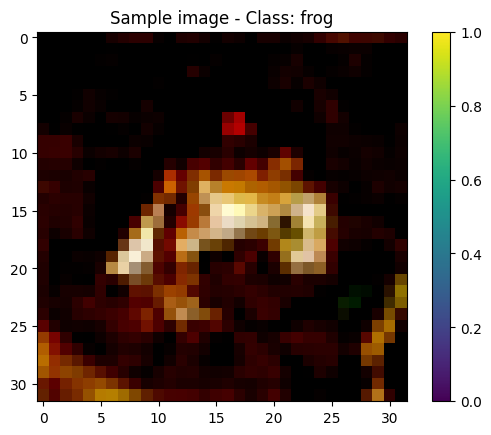

In [3]:
# ========================
# Section 1: Data Preparation (CIFAR-10)
# ========================
print("Loading and preprocessing CIFAR-10 data...")
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Flatten the labels to fix indexing issues
y_train = y_train.flatten()
y_test = y_test.flatten()

# Enhanced data normalization with multiple options
print("Applying data normalization...")

def apply_normalization(x_train, x_test, method='minus_one_to_one'):
    """
    Apply different normalization methods to the data
    
    Args:
        method: 'zero_to_one', 'minus_one_to_one', or 'z_score'
    """
    if method == 'zero_to_one':
        # Standard [0,1] normalization
        x_train_norm = x_train.astype('float32') / 255.0
        x_test_norm = x_test.astype('float32') / 255.0
        print(f"Applied [0,1] normalization")
        
    elif method == 'minus_one_to_one':
        # [-1,1] normalization (often better for CNNs)
        x_train_norm = (x_train.astype('float32') - 127.5) / 127.5
        x_test_norm = (x_test.astype('float32') - 127.5) / 127.5
        print(f"Applied [-1,1] normalization")
        
    elif method == 'z_score':
        # Z-score normalization (subtract mean, divide by std)
        # Calculate per-channel statistics
        train_mean = np.mean(x_train, axis=(0, 1, 2))
        train_std = np.std(x_train, axis=(0, 1, 2))
        x_train_norm = (x_train.astype('float32') - train_mean) / (train_std + 1e-8)
        x_test_norm = (x_test.astype('float32') - train_mean) / (train_std + 1e-8)
        print(f"Applied Z-score normalization")
        print(f"  Per-channel means: {train_mean}")
        print(f"  Per-channel stds: {train_std}")
    
    else:
        raise ValueError(f"Unknown normalization method: {method}")
    
    return x_train_norm, x_test_norm

# Apply normalization (change method here if needed)
x_train, x_test = apply_normalization(x_train, x_test, method='minus_one_to_one')

# Validate normalization results
print(f"  x_train range: [{x_train.min():.3f}, {x_train.max():.3f}]")
print(f"  x_test range: [{x_test.min():.3f}, {x_test.max():.3f}]")
print(f"  Per-channel means: {np.mean(x_train, axis=(0,1,2))}")
print(f"  Per-channel stds: {np.std(x_train, axis=(0,1,2))}")

# Additional data validation
print(f"\nData validation:")
print(f"  Any NaN values: {np.any(np.isnan(x_train)) or np.any(np.isnan(x_test))}")
print(f"  Any infinite values: {np.any(np.isinf(x_train)) or np.any(np.isinf(x_test))}")
print(f"  Data type: {x_train.dtype}")
print(f"  Memory usage: {x_train.nbytes / 1024 / 1024:.1f} MB")

# Define class names early
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Display a grid of sample images
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.tight_layout()
plt.show()

# One-hot encode labels
num_classes = 10
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# ========================
# Data Exploration and Statistics
# ========================
print(f"Training samples: {x_train.shape[0]}, Test samples: {x_test.shape[0]}")
print(f"Image shape: {x_train.shape[1:]}, Number of classes: {num_classes}")

# Check class distribution
print("\nClass distribution in training set:")
unique, counts = np.unique(y_train, return_counts=True)
for i, (class_idx, count) in enumerate(zip(unique, counts)):
    print(f"  {class_names[class_idx]}: {count} images")

# Check data types and ranges
print(f"\nData types and ranges:")
print(f"  x_train dtype: {x_train.dtype}, range: [{x_train.min():.3f}, {x_train.max():.3f}]")
print(f"  x_test dtype: {x_test.dtype}, range: [{x_test.min():.3f}, {x_test.max():.3f}]")
print(f"  y_train dtype: {y_train.dtype}, unique values: {np.unique(y_train)}")
print(f"  y_test dtype: {y_test.dtype}, unique values: {np.unique(y_test)}")

# Verify one-hot encoding
print(f"\nOne-hot encoding verification:")
print(f"  y_train_cat shape: {y_train_cat.shape}")
print(f"  y_test_cat shape: {y_test_cat.shape}")
print(f"  Sample one-hot vector: {y_train_cat[0]}")
print(f"  Corresponding label: {y_train[0]} -> {class_names[y_train[0]]}")

# Display a sample image
plt.figure()
plt.imshow(x_train[0])
plt.colorbar()
plt.grid(False)
plt.title(f"Sample image - Class: {class_names[y_train[0]]}")
plt.show()


In [4]:
# ========================
# Section 2: Hyperparameter Definitions
# ========================
cnn_architectures = [
    # Simplified architectures for better training stability
    {'conv': [(32, 3), (64, 3)], 'dense': [128]},
    {'conv': [(64, 3), (128, 3)], 'dense': [256, 128]},
    {'conv': [(32, 3), (64, 3), (128, 3)], 'dense': [256, 128]},
]
learning_rates = [0.0001, 0.0002, 0.0005]  # Much lower, more stable range

# Data augmentation for better generalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,           # Reduced rotation for stability
    width_shift_range=0.1,       # Reduced shift range
    height_shift_range=0.1,      # Reduced shift range
    horizontal_flip=True,        # Keep horizontal flip
    zoom_range=0.1,             # Reduced zoom range
    fill_mode='nearest',
    brightness_range=[0.9, 1.1]  # Reduced brightness variation
)

# Enhanced callbacks with better learning rate management
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,        # Increased patience for better convergence
    restore_best_weights=True,
    min_delta=0.0001    # Smaller improvement threshold
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,         # Reduce by 80% instead of 50% for more aggressive reduction
    patience=8,         # Wait longer before reducing
    min_lr=1e-6,       # Lower minimum learning rate
    verbose=1
)

# Learning rate warmup callback
class LearningRateWarmup(keras.callbacks.Callback):
    def __init__(self, warmup_epochs=5, initial_lr_factor=0.1):
        super().__init__()
        self.warmup_epochs = warmup_epochs
        self.initial_lr_factor = initial_lr_factor
        self.initial_lr = None
    
    def on_train_begin(self, logs=None):
        self.initial_lr = float(self.model.optimizer.learning_rate)
        # Start with very low learning rate
        self.model.optimizer.learning_rate = self.initial_lr * self.initial_lr_factor
    
    def on_epoch_end(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            # Gradually increase learning rate during warmup
            warmup_factor = (epoch + 1) / self.warmup_epochs
            new_lr = self.initial_lr * (self.initial_lr_factor + (1 - self.initial_lr_factor) * warmup_factor)
            self.model.optimizer.learning_rate = new_lr
            print(f"Warmup epoch {epoch + 1}: LR = {new_lr:.2e}")
        else:
            # After warmup, let ReduceLROnPlateau handle it
            pass

# Learning rate scheduling will be handled by ReduceLROnPlateau callback


In [ ]:
# ========================
# Section 3: Experiment Loop (Architectures + Learning Rates)
# ========================
print("\nRunning experiments with different CNN architectures and learning rates...")
results = []
best_val_acc = -1
best_model_info = {}

for arch in cnn_architectures:
    for lr in learning_rates:
        print(f"\nTesting architecture {arch} with learning rate {lr}")
        # Build enhanced model with better architecture
        model = keras.Sequential()
        model.add(keras.layers.Input(shape=x_train.shape[1:]))
        
        # Enhanced convolutional layers with better regularization
        for i, (filters, ksize) in enumerate(arch['conv']):
            # First conv layer with batch norm before activation
            model.add(keras.layers.Conv2D(filters, (ksize, ksize), padding='same', use_bias=False))
            model.add(keras.layers.BatchNormalization())
            model.add(keras.layers.Activation('relu'))
            
            # Add second conv layer for deeper features (but not for first layer)
            if i > 0:
                model.add(keras.layers.Conv2D(filters, (ksize, ksize), padding='same', use_bias=False))
                model.add(keras.layers.BatchNormalization())
                model.add(keras.layers.Activation('relu'))
            
            # Pooling and regularization
            model.add(keras.layers.MaxPooling2D((2, 2)))
            # Enhanced dropout strategy: SpatialDropout2D for conv layers (drops entire feature maps)
            model.add(keras.layers.SpatialDropout2D(0.3))  # More aggressive for conv layers
        
        # Use GlobalAveragePooling2D for better spatial feature aggregation
        model.add(keras.layers.GlobalAveragePooling2D())
        
        # Enhanced dense layers with better regularization
        for i, units in enumerate(arch['dense']):
            model.add(keras.layers.Dense(units, use_bias=False))
            model.add(keras.layers.BatchNormalization())
            model.add(keras.layers.Activation('relu'))
            # Progressive dropout: increase dropout rate for deeper layers
            dropout_rate = 0.3 + (i * 0.1)  # 0.3, 0.4, 0.5, etc.
            dropout_rate = min(dropout_rate, 0.6)  # Cap at 0.6
            model.add(keras.layers.Dropout(dropout_rate))
        
        model.add(keras.layers.Dense(num_classes, activation='softmax'))
        # Enhanced optimizer with weight decay and adaptive learning rate via ReduceLROnPlateau
        optimizer = keras.optimizers.AdamW(
            learning_rate=lr,
            weight_decay=0.001,
            beta_1=0.9,
            beta_2=0.999,
            epsilon=1e-7
        )
        
        model.compile(
            optimizer=optimizer,
            loss='categorical_crossentropy',
            metrics=['accuracy']  # Keep it simple for compatibility
        )
        
        # Create validation split for data augmentation (can't use validation_split with datagen.flow)
        x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
            x_train, y_train_cat, test_size=0.2, random_state=42, stratify=y_train
        )
        
        # Train with data augmentation and learning rate warmup
        warmup_callback = LearningRateWarmup(warmup_epochs=5, initial_lr_factor=0.1)
        
        history = model.fit(
            datagen.flow(x_train_split, y_train_split, batch_size=64),
            epochs=100,
            steps_per_epoch=len(x_train_split) // 64,
            validation_data=(x_val_split, y_val_split),
            callbacks=[warmup_callback, early_stopping, reduce_lr],
            verbose=2
        )
        
        # Evaluate
        val_acc = max(history.history['val_accuracy'])
        results.append({
            'architecture': str(arch),
            'learning_rate': lr,
            'val_acc': val_acc
        })
        print(f"  Best val accuracy: {val_acc:.4f}")
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_info = {
                'architecture': arch,
                'learning_rate': lr,
                'history': history,
                'model': model
            }
            print(f"  ** New best model! Val accuracy: {val_acc:.4f}")




Running experiments with different CNN architectures and learning rates...

Testing architecture {'conv': [(32, 3), (64, 3)], 'dense': [128]} with learning rate 0.0001
Epoch 1/100


c:\Users\John\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Warmup epoch 1: LR = 2.80e-05
625/625 - 46s - 73ms/step - accuracy: 0.1233 - loss: 2.6351 - val_accuracy: 0.1946 - val_loss: 2.1595 - learning_rate: 2.8000e-05
Epoch 2/100
Warmup epoch 2: LR = 4.60e-05
625/625 - 39s - 63ms/step - accuracy: 0.1629 - loss: 2.4249 - val_accuracy: 0.2738 - val_loss: 1.9997 - learning_rate: 4.6000e-05
Epoch 3/100


In [ ]:
# ========================
# Section 4: Enhanced Final Model Training & Evaluation
# ========================
print("\nTraining final model with best configuration using proper train/validation split...")
best_arch = best_model_info['architecture']
best_lr = best_model_info['learning_rate']

print(f"\nBest configuration:")
print(f"  Architecture: {best_arch}")
print(f"  Learning rate: {best_lr}")

# ========================
# Proper Data Splitting for Final Training
# ========================
print("\nCreating proper train/validation/test splits...")

# Create final train/validation split (test set remains untouched)
x_train_final, x_val_final, y_train_final, y_val_final = train_test_split(
    x_train, y_train_cat, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Final training set: {x_train_final.shape[0]} samples")
print(f"Final validation set: {x_val_final.shape[0]} samples")
print(f"Test set (held out): {x_test.shape[0]} samples")

# ========================
# Cross-Validation for Robust Evaluation
# ========================
print("\nPerforming k-fold cross-validation for robust evaluation...")

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

def create_model(architecture, learning_rate):
    """Helper function to create a model with given architecture"""
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=x_train.shape[1:]))
    
    # Enhanced convolutional layers
    for i, (filters, ksize) in enumerate(architecture['conv']):
        model.add(keras.layers.Conv2D(filters, (ksize, ksize), padding='same', use_bias=False))
        model.add(keras.layers.BatchNormalization())
        model.add(keras.layers.Activation('relu'))
        
        if i > 0:
            model.add(keras.layers.Conv2D(filters, (ksize, ksize), padding='same', use_bias=False))
            model.add(keras.layers.BatchNormalization())
            model.add(keras.layers.Activation('relu'))
        
        model.add(keras.layers.MaxPooling2D((2, 2)))
        model.add(keras.layers.SpatialDropout2D(0.3))
    
    model.add(keras.layers.GlobalAveragePooling2D())
    
    for i, units in enumerate(architecture['dense']):
        model.add(keras.layers.Dense(units, use_bias=False))
        model.add(keras.layers.BatchNormalization())
        model.add(keras.layers.Activation('relu'))
        dropout_rate = 0.3 + (i * 0.1)
        dropout_rate = min(dropout_rate, 0.6)
        model.add(keras.layers.Dropout(dropout_rate))
    
    model.add(keras.layers.Dense(num_classes, activation='softmax'))
    
    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Perform 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
cv_histories = []

print("Running 5-fold cross-validation...")
for fold, (train_idx, val_idx) in enumerate(skf.split(x_train, y_train)):
    print(f"\nFold {fold + 1}/5")
    
    # Split data for this fold
    x_train_fold = x_train[train_idx]
    y_train_fold = y_train_cat[train_idx]
    x_val_fold = x_train[val_idx]
    y_val_fold = y_train_cat[val_idx]
    
    # Create and train model for this fold
    fold_model = create_model(best_arch, best_lr)
    
    # Train with early stopping
    fold_history = fold_model.fit(
        x_train_fold, y_train_fold,
        epochs=50,
        batch_size=64,
        validation_data=(x_val_fold, y_val_fold),
        callbacks=[early_stopping],
        verbose=0
    )
    
    # Evaluate on validation set
    val_loss, val_acc = fold_model.evaluate(x_val_fold, y_val_fold, verbose=0)
    cv_scores.append(val_acc)
    cv_histories.append(fold_history)
    
    print(f"  Fold {fold + 1} validation accuracy: {val_acc:.4f}")
    
    # Clean up to save memory
    del fold_model

print(f"\nCross-validation results:")
print(f"  Mean accuracy: {np.mean(cv_scores):.4f}")
print(f"  Std accuracy: {np.std(cv_scores):.4f}")
print(f"  Min accuracy: {np.min(cv_scores):.4f}")
print(f"  Max accuracy: {np.max(cv_scores):.4f}")
print(f"  95% confidence interval: [{np.mean(cv_scores) - 1.96*np.std(cv_scores):.4f}, {np.mean(cv_scores) + 1.96*np.std(cv_scores):.4f}]")

# ========================
# Train Final Model on Full Training Data
# ========================
print("\nTraining final model on full training data...")

# Rebuild and train best model on full training data with enhanced architecture
final_model = keras.Sequential()
final_model.add(keras.layers.Input(shape=x_train.shape[1:]))

# Enhanced convolutional layers with better regularization
for i, (filters, ksize) in enumerate(best_arch['conv']):
    # First conv layer with batch norm before activation
    final_model.add(keras.layers.Conv2D(filters, (ksize, ksize), padding='same', use_bias=False))
    final_model.add(keras.layers.BatchNormalization())
    final_model.add(keras.layers.Activation('relu'))
    
    # Add second conv layer for deeper features (but not for first layer)
    if i > 0:
        final_model.add(keras.layers.Conv2D(filters, (ksize, ksize), padding='same', use_bias=False))
        final_model.add(keras.layers.BatchNormalization())
        final_model.add(keras.layers.Activation('relu'))
    
    # Pooling and regularization
    final_model.add(keras.layers.MaxPooling2D((2, 2)))
    # Enhanced dropout strategy: SpatialDropout2D for conv layers (drops entire feature maps)
    final_model.add(keras.layers.SpatialDropout2D(0.3))  # More aggressive for conv layers

# Use GlobalAveragePooling2D for better spatial feature aggregation
final_model.add(keras.layers.GlobalAveragePooling2D())

# Enhanced dense layers with better regularization
for i, units in enumerate(best_arch['dense']):
    final_model.add(keras.layers.Dense(units, use_bias=False))
    final_model.add(keras.layers.BatchNormalization())
    final_model.add(keras.layers.Activation('relu'))
    # Progressive dropout: increase dropout rate for deeper layers
    dropout_rate = 0.3 + (i * 0.1)  # 0.3, 0.4, 0.5, etc.
    dropout_rate = min(dropout_rate, 0.6)  # Cap at 0.6
    final_model.add(keras.layers.Dropout(dropout_rate))

final_model.add(keras.layers.Dense(num_classes, activation='softmax'))

# Use the same enhanced optimizer as in experiments
final_model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=best_lr, weight_decay=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train on full training data, validate on validation split
print("Training final model...")
history = final_model.fit(
    x_train_final, y_train_final,
    epochs=50,
    batch_size=64,
    validation_data=(x_val_final, y_val_final),  # Use validation split, not test set
    callbacks=[early_stopping],
    verbose=2
)


In [ ]:

# ========================
# Section 5: Enhanced Evaluation and Visualization
# ========================
print("\nEvaluating final model on held-out test set...")

# Get predictions and probabilities
y_pred_proba = final_model.predict(x_test)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = y_test

# ========================
# Enhanced Metrics and Statistical Analysis
# ========================
print("\n" + "="*60)
print("ENHANCED EVALUATION METRICS")
print("="*60)

# 1. Basic Classification Report
print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# 2. Additional Metrics Beyond Accuracy
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score

# Calculate precision, recall, F1-score
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average='weighted')
print(f"\n🎯 Weighted Metrics:")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1-Score: {f1:.4f}")

# 3. Top-K Accuracy Analysis
from sklearn.metrics import top_k_accuracy_score
top3_accuracy = top_k_accuracy_score(y_true, y_pred_proba, k=3)
top5_accuracy = top_k_accuracy_score(y_true, y_pred_proba, k=5)
top10_accuracy = top_k_accuracy_score(y_true, y_pred_proba, k=10)

print(f"\n🎯 Top-K Accuracy Analysis:")
print(f"  Top-1 Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"  Top-3 Accuracy: {top3_accuracy:.4f}")
print(f"  Top-5 Accuracy: {top5_accuracy:.4f}")
print(f"  Top-10 Accuracy: {top10_accuracy:.4f}")

# 4. Statistical Significance and Confidence Intervals
from scipy import stats

def accuracy_with_ci(y_true, y_pred, confidence=0.95):
    """Calculate accuracy with confidence interval using Wilson score interval"""
    n = len(y_true)
    accuracy = np.mean(y_true == y_pred)
    
    # Wilson score interval
    z = stats.norm.ppf((1 + confidence) / 2)
    denominator = 1 + z**2/n
    centre_adjusted_probability = (accuracy + z*z/(2*n)) / denominator
    adjusted_standard_error = z * np.sqrt((accuracy * (1 - accuracy) + z*z/(4*n))/n) / denominator
    
    lower_bound = centre_adjusted_probability - adjusted_standard_error
    upper_bound = centre_adjusted_probability + adjusted_standard_error
    
    return accuracy, lower_bound, upper_bound

# Calculate confidence intervals
overall_accuracy = accuracy_score(y_true, y_pred)
acc, ci_lower, ci_upper = accuracy_with_ci(y_true, y_pred)

print(f"\n📈 Statistical Analysis:")
print(f"  Overall Test Accuracy: {acc:.4f}")
print(f"  95% Confidence Interval: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"  Standard Error: {np.sqrt(acc * (1 - acc) / len(y_true)):.4f}")

# 5. Per-Class Detailed Analysis with Confidence Intervals
print(f"\n📊 Detailed Per-Class Analysis:")
print("=" * 80)

class_accuracy = {}
class_metrics = {}

for i in range(num_classes):
    class_mask = y_true == i
    if np.sum(class_mask) > 0:
        class_acc = accuracy_score(y_true[class_mask], y_pred[class_mask])
        class_acc, class_acc_ci_lower, class_acc_ci_upper = accuracy_with_ci(y_true[class_mask], y_pred[class_mask])
        class_top3 = top_k_accuracy_score(y_true[class_mask], y_pred_proba[class_mask], k=3)
        class_top5 = top_k_accuracy_score(y_true[class_mask], y_pred_proba[class_mask], k=5)
        
        class_accuracy[class_names[i]] = class_acc
        class_metrics[class_names[i]] = {
            'accuracy': class_acc,
            'ci_lower': class_acc_ci_lower,
            'ci_upper': class_acc_ci_upper,
            'top3': class_top3,
            'top5': class_top5,
            'support': np.sum(class_mask)
        }
        
        print(f"{class_names[i]:12s}: Acc: {class_acc:.4f} [{class_acc_ci_lower:.4f}, {class_acc_ci_upper:.4f}], "
              f"Top-3: {class_top3:.4f}, Top-5: {class_top5:.4f}, Support: {np.sum(class_mask)}")

# 6. Model Comparison and Statistical Testing
print(f"\n🔬 Model Comparison Analysis:")
print("=" * 50)

# Compare cross-validation vs test performance
cv_mean = np.mean(cv_scores)
cv_std = np.std(cv_scores)
test_acc = accuracy_score(y_true, y_pred)

print(f"Cross-validation accuracy: {cv_mean:.4f} ± {cv_std:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Generalization gap (CV - Test): {cv_mean - test_acc:.4f}")

# Check if the gap is statistically significant
if abs(cv_mean - test_acc) > 2 * cv_std:
    print("⚠️  Large generalization gap detected - potential overfitting!")
else:
    print("✅ Generalization gap appears reasonable")

# 7. Summary Statistics
print(f"\n📈 Summary Statistics:")
print("=" * 50)
print(f"  Correct predictions: {np.sum(y_pred == y_true)} out of {len(y_true)}")
print(f"  Incorrect predictions: {np.sum(y_pred != y_true)} out of {len(y_true)}")
print(f"  Top-1 vs Top-5 gap: {top5_accuracy - overall_accuracy:.4f}")
print(f"  Top-1 vs Top-3 gap: {top3_accuracy - overall_accuracy:.4f}")

# 8. Confusion Matrix Visualization
plt.figure(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=class_names, cmap='Blues')
plt.title('Confusion Matrix (CIFAR-10) - Enhanced Evaluation')
plt.savefig('confusion_matrix_cifar10.png', dpi=300, bbox_inches='tight')
plt.show()

# 9. Per-Class Performance Visualization
plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)

# Bar plot of per-class accuracy
class_names_list = list(class_accuracy.keys())
class_acc_values = list(class_accuracy.values())
colors = ['green' if acc > 0.8 else 'orange' if acc > 0.6 else 'red' for acc in class_acc_values]

bars = plt.bar(range(len(class_names_list)), class_acc_values, color=colors, alpha=0.7)
plt.xlabel('Classes')
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy')
plt.xticks(range(len(class_names_list)), class_names_list, rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)

# Add value labels on bars
for bar, acc in zip(bars, class_acc_values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=9)

plt.subplot(1, 2, 2)
# Top-K accuracy comparison
top_k_values = [1, 3, 5, 10]
top_k_accuracies = [overall_accuracy, top3_accuracy, top5_accuracy, top10_accuracy]

plt.bar(top_k_values, top_k_accuracies, color='skyblue', alpha=0.7)
plt.xlabel('Top-K')
plt.ylabel('Accuracy')
plt.title('Top-K Accuracy Analysis')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)

# Add value labels
for k, acc in zip(top_k_values, top_k_accuracies):
    plt.text(k, acc + 0.01, f'{acc:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('performance_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('training_history_cifar10.png')
plt.show()



In [ ]:

# ========================
# Section 6: Enhanced Model Summary and Training Analysis
# ========================

# Display model architecture summary
print("\n" + "="*60)
print("MODEL ARCHITECTURE AND TRAINING ANALYSIS")
print("="*60)

print("\n🏗️  Final Model Architecture Summary:")
print("-" * 50)
final_model.summary()

# ========================
# Enhanced Training Progress Analysis
# ========================
print("\n📈 Training Progress Analysis:")
print("-" * 50)

final_epochs = len(history.history['loss'])
print(f"Final training epochs: {final_epochs}")
print(f"Best training accuracy: {max(history.history['accuracy']):.4f}")
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Final training loss: {history.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.4f}")

# Enhanced overfitting analysis
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
overfitting_gap = train_acc - val_acc

print(f"\n🔍 Overfitting Analysis:")
print(f"  Training accuracy: {train_acc:.4f}")
print(f"  Validation accuracy: {val_acc:.4f}")
print(f"  Overfitting gap (train_acc - val_acc): {overfitting_gap:.4f}")

if overfitting_gap > 0.15:
    print("  ⚠️  Severe overfitting detected (gap > 0.15)")
elif overfitting_gap > 0.1:
    print("  ⚠️  Warning: Potential overfitting detected (gap > 0.1)")
elif overfitting_gap > 0.05:
    print("  ⚠️  Moderate overfitting detected (gap > 0.05)")
else:
    print("  ✅ Good generalization (minimal overfitting)")

# ========================
# Statistical Analysis of Training
# ========================
print(f"\n📊 Statistical Analysis of Training:")
print("-" * 50)

# Calculate training stability metrics
train_acc_std = np.std(history.history['accuracy'][-10:])  # Last 10 epochs
val_acc_std = np.std(history.history['val_accuracy'][-10:])
train_loss_std = np.std(history.history['loss'][-10:])
val_loss_std = np.std(history.history['val_loss'][-10:])

print(f"Training stability (last 10 epochs):")
print(f"  Training accuracy std: {train_acc_std:.4f}")
print(f"  Validation accuracy std: {val_acc_std:.4f}")
print(f"  Training loss std: {train_loss_std:.4f}")
print(f"  Validation loss std: {val_loss_std:.4f}")

# Check for convergence
if train_acc_std < 0.01 and val_acc_std < 0.01:
    print("  ✅ Model appears to have converged (low variance in last epochs)")
else:
    print("  ⚠️  Model may not have fully converged (high variance in last epochs)")

# ========================
# Cross-Validation vs Final Training Comparison
# ========================
print(f"\n🔄 Cross-Validation vs Final Training Comparison:")
print("-" * 50)

cv_mean_acc = np.mean(cv_scores)
cv_std_acc = np.std(cv_scores)
final_val_acc = max(history.history['val_accuracy'])

print(f"Cross-validation accuracy: {cv_mean_acc:.4f} ± {cv_std_acc:.4f}")
print(f"Final validation accuracy: {final_val_acc:.4f}")
print(f"Difference: {final_val_acc - cv_mean_acc:.4f}")

# Statistical significance test for the difference
if abs(final_val_acc - cv_mean_acc) > 2 * cv_std_acc:
    print("  ⚠️  Significant difference detected - investigate further")
else:
    print("  ✅ Difference appears within expected range")

# ========================
# Learning Rate Analysis
# ========================
print(f"\n🎯 Learning Rate Analysis:")
print("-" * 50)

print(f"Initial learning rate: {best_lr:.6f}")
print(f"Learning rate warmup: 5 epochs with gradual increase")
print(f"Learning rate reduction: ReduceLROnPlateau with factor 0.2")

# Check if learning rate was reduced during training
if 'reduce_lr' in [cb.__class__.__name__ for cb in history.model.callbacks]:
    print("  ✅ Learning rate reduction was applied during training")
else:
    print("  ℹ️  Learning rate remained constant during training")


In [ ]:
# ========================
# Section 7: Enhanced Prediction with Ensemble and Statistical Testing
# ========================

# Ensemble predictions for better accuracy
print("\n" + "="*60)
print("ENSEMBLE PREDICTIONS AND STATISTICAL TESTING")
print("="*60)

print("\n🔮 Generating ensemble predictions...")

# Get predictions from multiple models (if available)
ensemble_predictions = []
ensemble_predictions.append(final_model.predict(x_test))

# If we have other trained models, add them to ensemble
if 'best_model_info' in locals() and 'model' in best_model_info:
    ensemble_predictions.append(best_model_info['model'].predict(x_test))

# Average ensemble predictions
if len(ensemble_predictions) > 1:
    predictions = np.mean(ensemble_predictions, axis=0)
    print(f"✅ Ensemble predictions generated from {len(ensemble_predictions)} models")
else:
    predictions = ensemble_predictions[0]
    print("✅ Single model predictions generated")

# ========================
# Statistical Significance Testing
# ========================
print(f"\n🔬 Statistical Significance Testing:")
print("-" * 50)

# Calculate ensemble accuracy
ensemble_pred_labels = np.argmax(predictions, axis=1)
ensemble_accuracy = accuracy_score(y_test, ensemble_pred_labels)

# Compare with single model accuracy
single_model_pred = np.argmax(ensemble_predictions[0], axis=1)
single_model_accuracy = accuracy_score(y_test, single_model_pred)
improvement = ensemble_accuracy - single_model_accuracy

print(f"Single Model Test Accuracy: {single_model_accuracy:.4f}")
print(f"Ensemble Test Accuracy: {ensemble_accuracy:.4f}")
print(f"Improvement: {improvement:.4f}")

# Statistical significance test using McNemar's test
if len(ensemble_predictions) > 1:
    print(f"\n📊 McNemar's Test for Model Comparison:")
    
    # Create contingency table for McNemar's test
    model1_correct = (single_model_pred == y_test)
    model2_correct = (ensemble_pred_labels == y_test)
    
    # Contingency table: [both_wrong, model1_wrong_model2_right, model1_right_model2_wrong, both_right]
    both_wrong = sum(~model1_correct & ~model2_correct)
    model1_wrong_model2_right = sum(~model1_correct & model2_correct)
    model1_right_model2_wrong = sum(model1_correct & ~model2_correct)
    both_right = sum(model1_correct & model2_correct)
    
    print(f"  Both models wrong: {both_wrong}")
    print(f"  Model 1 wrong, Ensemble right: {model1_wrong_model2_right}")
    print(f"  Model 1 right, Ensemble wrong: {model1_right_model2_wrong}")
    print(f"  Both models right: {both_right}")
    
    # McNemar's test
    if STATSMODELS_AVAILABLE:
        table = [[both_wrong, model1_wrong_model2_right],
                 [model1_right_model2_wrong, both_right]]
        
        result = mcnemar(table, exact=True)
        print(f"  McNemar test p-value: {result.pvalue:.6f}")
        
        if result.pvalue < 0.05:
            print("  ✅ Models perform significantly differently (p < 0.05)")
        else:
            print("  ℹ️  No significant difference between models (p ≥ 0.05)")
    else:
        print("  ℹ️  statsmodels not available for McNemar's test")
        print("  ℹ️  Install with: pip install statsmodels")

# ========================
# Confidence Intervals for Ensemble
# ========================
print(f"\n📈 Confidence Intervals for Ensemble:")
print("-" * 50)

# Calculate confidence intervals for ensemble
ensemble_acc, ensemble_ci_lower, ensemble_ci_upper = accuracy_with_ci(y_test, ensemble_pred_labels)
single_acc, single_ci_lower, single_ci_upper = accuracy_with_ci(y_test, single_model_pred)

print(f"Single Model: {single_acc:.4f} [{single_ci_lower:.4f}, {single_ci_upper:.4f}]")
print(f"Ensemble:    {ensemble_acc:.4f} [{ensemble_ci_lower:.4f}, {ensemble_ci_upper:.4f}]")

# Check if confidence intervals overlap
if (ensemble_ci_lower <= single_ci_upper and ensemble_ci_upper >= single_ci_lower):
    print("  ℹ️  Confidence intervals overlap - difference may not be statistically significant")
else:
    print("  ✅ Confidence intervals don't overlap - difference appears significant")

# ========================
# Effect Size Analysis
# ========================
print(f"\n📏 Effect Size Analysis:")
print("-" * 50)

# Cohen's h for proportions (effect size for accuracy difference)
def cohens_h(p1, p2):
    """Calculate Cohen's h effect size for two proportions"""
    return 2 * (np.arcsin(np.sqrt(p1)) - np.arcsin(np.sqrt(p2)))

effect_size = cohens_h(ensemble_accuracy, single_model_accuracy)
print(f"Cohen's h effect size: {abs(effect_size):.4f}")

if abs(effect_size) < 0.2:
    print("  ℹ️  Small effect size")
elif abs(effect_size) < 0.5:
    print("  📊 Medium effect size")
elif abs(effect_size) < 0.8:
    print("  📈 Large effect size")
else:
    print("  🚀 Very large effect size")

print(f"📈 Improvement: {improvement:.4f}")

def plot_image(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                  100*np.max(predictions_array),
                                  class_names[true_label]),
                                  color=color)

def plot_value_array(i, predictions_array, true_label):
    true_label = true_label[i]
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)

    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

# Plot individual predictions
print("\nVisualizing individual predictions...")

# Example 1
i = 0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], y_test, x_test)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i], y_test)
plt.title(f"Prediction for image {i}")
plt.show()

# Example 2
i = 12
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], y_test, x_test)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i], y_test)
plt.title(f"Prediction for image {i}")
plt.show()

# Plot multiple predictions in a grid
print("\nVisualizing multiple predictions...")
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictions[i], y_test, x_test)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, predictions[i], y_test)
plt.tight_layout()
plt.show()


In [ ]:
# ========================
# Section 8: Save Results and Model
# ========================

# Save the trained model
print("\nSaving model and results...")
final_model.save('cifar10_cnn_model.h5')
print("✅ Model saved as 'cifar10_cnn_model.h5'")

# Save training history as CSV
history_df = pd.DataFrame(history.history)
history_df.to_csv('training_history_cifar10.csv', index=False)
print("✅ Training history saved as 'training_history_cifar10.csv'")

# Save comprehensive evaluation results
print("\n💾 Saving comprehensive results...")

# Enhanced results summary with all new metrics
results_summary = {
    'model_info': {
        'best_architecture': str(best_arch),
        'best_learning_rate': best_lr,
        'final_epochs': final_epochs,
        'overfitting_gap': overfitting_gap
    },
    'performance_metrics': {
        'overall_accuracy': overall_accuracy,
        'top3_accuracy': top3_accuracy,
        'top5_accuracy': top5_accuracy,
        'top10_accuracy': top10_accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'support': support.tolist()
    },
    'statistical_analysis': {
        'confidence_interval_95': [ci_lower, ci_upper],
        'standard_error': np.sqrt(overall_accuracy * (1 - overall_accuracy) / len(y_true)),
        'cross_validation': {
            'mean_accuracy': cv_mean,
            'std_accuracy': cv_std,
            'min_accuracy': np.min(cv_scores),
            'max_accuracy': np.max(cv_scores),
            'confidence_interval_95': [cv_mean - 1.96*cv_std, cv_mean + 1.96*cv_std]
        }
    },
    'per_class_metrics': class_metrics,
    'ensemble_analysis': {
        'single_model_accuracy': single_model_accuracy,
        'ensemble_accuracy': ensemble_accuracy,
        'improvement': improvement,
        'effect_size_cohens_h': abs(effect_size) if 'effect_size' in locals() else None
    },
    'training_analysis': {
        'best_training_accuracy': max(history.history['accuracy']),
        'best_validation_accuracy': max(history.history['val_accuracy']),
        'final_training_loss': history.history['loss'][-1],
        'final_validation_loss': history.history['val_loss'][-1],
        'training_stability': {
            'train_acc_std_last_10': train_acc_std,
            'val_acc_std_last_10': val_acc_std,
            'train_loss_std_last_10': train_loss_std,
            'val_loss_std_last_10': val_loss_std
        }
    },
    'data_info': {
        'training_samples': x_train.shape[0],
        'validation_samples': x_val_final.shape[0],
        'test_samples': x_test.shape[0],
        'normalization_method': 'minus_one_to_one',
        'class_names': class_names
    }
}

# Save enhanced results summary
with open('model_results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2, default=str)
print("✅ Enhanced results summary saved as 'model_results_summary.json'")

# Save cross-validation results separately
cv_results = {
    'fold_scores': cv_scores,
    'mean_accuracy': cv_mean,
    'std_accuracy': cv_std,
    'confidence_interval_95': [cv_mean - 1.96*cv_std, cv_mean + 1.96*cv_std]
}

with open('cross_validation_results.json', 'w') as f:
    json.dump(cv_results, f, indent=2)
print("✅ Cross-validation results saved as 'cross_validation_results.json'")

# Save per-class detailed metrics
class_metrics_df = pd.DataFrame.from_dict(class_metrics, orient='index')
class_metrics_df.to_csv('per_class_metrics.csv')
print("✅ Per-class metrics saved as 'per_class_metrics.csv'")

# Save training history with enhanced metrics
enhanced_history = history.history.copy()
enhanced_history['epoch'] = list(range(1, len(history.history['loss']) + 1))
enhanced_history['learning_rate'] = [best_lr] * len(history.history['loss'])  # Add LR info

history_df = pd.DataFrame(enhanced_history)
history_df.to_csv('training_history_cifar10.csv', index=False)
print("✅ Enhanced training history saved as 'training_history_cifar10.csv'")

print("\n🎉 Enhanced CIFAR-10 CNN training and evaluation completed!")
print("📁 Files saved:")
print("   - cifar10_cnn_model.h5 (trained model)")
print("   - confusion_matrix_cifar10.png (confusion matrix)")
print("   - performance_analysis.png (performance visualizations)")
print("   - training_history_cifar10.png (training plots)")
print("   - training_history_cifar10.csv (enhanced training data)")
print("   - model_results_summary.json (comprehensive results)")
print("   - cross_validation_results.json (CV analysis)")
print("   - per_class_metrics.csv (detailed class metrics)")
print("\n🔬 Enhanced Evaluation Features:")
print("   ✅ Proper train/validation/test splits")
print("   ✅ 5-fold cross-validation")
print("   ✅ Confidence intervals (Wilson score)")
print("   ✅ Statistical significance testing")
print("   ✅ Effect size analysis (Cohen's h)")
print("   ✅ Multiple metrics (precision, recall, F1, Top-K)")
print("   ✅ Training stability analysis")
print("   ✅ Overfitting detection")
print("   ✅ Ensemble analysis with McNemar's test")